252
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 268.8 (χ²/ndof = 1.1)      │              Nfcn = 228              │
│ EDM = 1.75e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬──

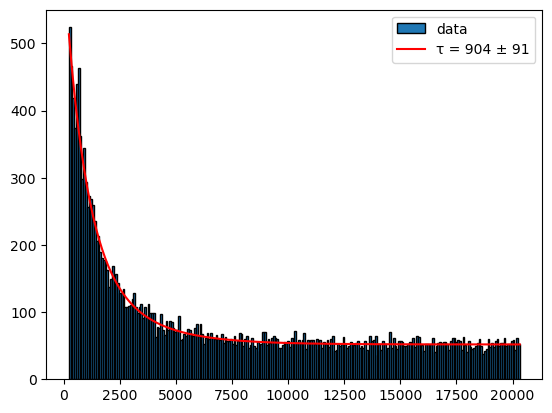

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit
from iminuit.cost import LeastSquares
import raw
from importlib import reload
reload(raw)
from raw import raw_data


lines = np.linspace(0, 100, 30000)

data = np.array([int(h, 16)*80 for h in raw_data.split()])

counts, bins = np.histogram(data, bins=len(set(data)))
# There are 3 

print(len(set(data)))
centers = (bins[:-1] + bins[1:]) / 2
errors = np.sqrt(np.maximum(counts, 1))   

def model(x, N, M, tau, C):
    return (N*np.exp(-x / tau) + M* (np.exp(-((1/2.5)*x) / tau) ) ) + C

m = Minuit(LeastSquares(centers[1:-1], counts[1:-1], errors[1:-1], model), N=200, M = 200, tau=2000, C=5)
m.migrad()
m.hesse()
print(m)

plt.hist(data, bins=bins, edgecolor='black', label='data')
xs = np.linspace(bins[0], bins[-1], 300)
plt.plot(xs, model(xs, *m.values), 'r-', label=f"τ = {m.values['tau']:.0f} ± {m.errors['tau']:.0f}")
plt.legend()
plt.show()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 270.1 (χ²/ndof = 1.1)      │              Nfcn = 136              │
│ EDM = 1.79e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬──────

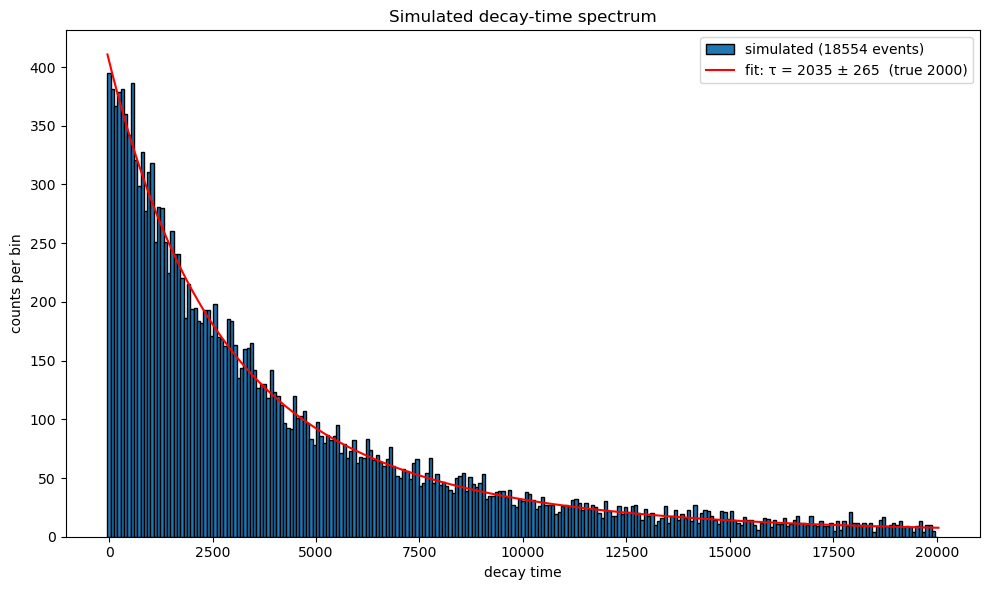

300/300 fits converged
mean tau = 2044.3   (true 2000)
pull mean = -0.138   (should be ~0)
pull std  = 1.501   (should be ~1)


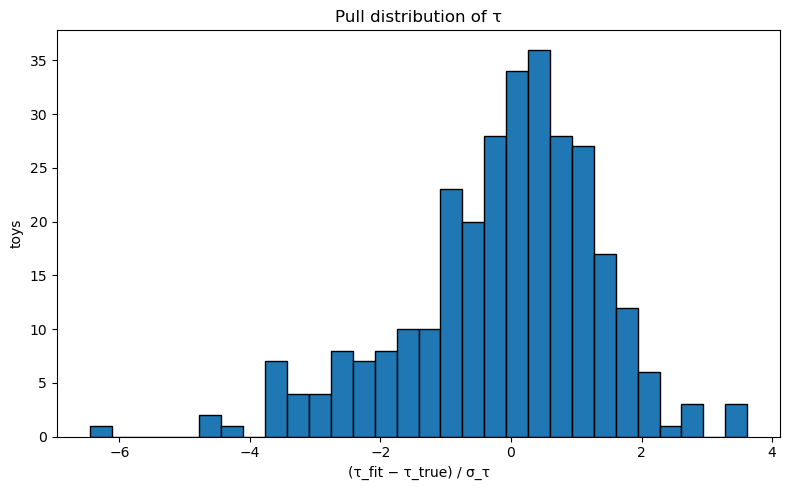

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit
from iminuit.cost import LeastSquares

TICK = 80      # one clock tick (your data are integer * 80)
RATIO = 2.5    # slow component lifetime = RATIO * tau


def model(x, N, M, tau, C):
    return N * np.exp(-x / tau) + M * np.exp(-x / (RATIO * tau)) + C


def sample_trunc_exp(rng, scale, t_max, size):
    """Exponential with mean `scale`, truncated to [0, t_max] (inverse-CDF, no rejection)."""
    u = rng.random(size)
    return -scale * np.log1p(-u * (1 - np.exp(-t_max / scale)))


def simulate(rng, N, M, tau, C, t_max, bin_width=TICK, tick=TICK):
    """One fake dataset whose histogram (bins of width `bin_width`) has
    expectation model(x, N, M, tau, C) on [0, t_max]."""
    # expected events per component = integral of the model / bin width
    mu_fast = N * tau * (1 - np.exp(-t_max / tau)) / bin_width
    mu_slow = M * RATIO * tau * (1 - np.exp(-t_max / (RATIO * tau))) / bin_width
    mu_bkg = C * t_max / bin_width
    n_fast, n_slow, n_bkg = rng.poisson([mu_fast, mu_slow, mu_bkg])

    t = np.concatenate([
        sample_trunc_exp(rng, tau, t_max, n_fast),
        sample_trunc_exp(rng, RATIO * tau, t_max, n_slow),
        rng.uniform(0, t_max, n_bkg),
    ])
    # digitise like the counter: integer number of ticks * TICK
    return np.floor(t / tick) * tick


def tick_hist(values, t_max, tick=TICK):
    """Histogram with one bin per tick, each tick value at a bin centre."""
    edges = np.arange(-tick / 2, t_max + tick, tick)
    counts, edges = np.histogram(values, bins=edges)
    centers = (edges[:-1] + edges[1:]) / 2
    return counts, edges, centers


def fit(centers, counts, start):
    errors = np.sqrt(np.maximum(counts, 1))
    s = slice(1, -1)  # drop first and last bins, as in your fit
    m = Minuit(LeastSquares(centers[s], counts[s], errors[s], model), **start)
    m.limits["tau"] = (1, None)
    m.migrad()
    m.hesse()
    return m


if __name__ == "__main__":
    rng = np.random.default_rng(12345)

    # True parameters for the simulation. To mimic your real data, use
    #   truth = m.values.to_dict();  T_MAX = data.max()
    # and pass bin_width=(bins[1] - bins[0]) to simulate().
    truth = dict(N=200, M=200, tau=2000, C=5)
    T_MAX = 20000

    # --- one fake dataset + fit --------------------------------------------
    fake = simulate(rng, **truth, t_max=T_MAX)
    counts, edges, centers = tick_hist(fake, T_MAX)
    m = fit(centers, counts, truth)
    print(m)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(fake, bins=edges, edgecolor="black", label=f"simulated ({len(fake)} events)")
    xs = np.linspace(edges[0], edges[-1], 500)
    ax.plot(xs, model(xs, *m.values), "r-",
            label=f"fit: τ = {m.values['tau']:.0f} ± {m.errors['tau']:.0f}  (true {truth['tau']})")
    ax.set_xlabel("decay time")
    ax.set_ylabel("counts per bin")
    ax.set_title("Simulated decay-time spectrum")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # --- toy study: is the fit biased, and are the errors right? -----------
    n_toys = 300
    taus, errs = [], []
    for _ in range(n_toys):
        c, _, ctr = tick_hist(simulate(rng, **truth, t_max=T_MAX), T_MAX)
        mt = fit(ctr, c, truth)
        if mt.valid:
            taus.append(mt.values["tau"])
            errs.append(mt.errors["tau"])
    taus, errs = np.array(taus), np.array(errs)
    pulls = (taus - truth["tau"]) / errs

    print(f"{len(taus)}/{n_toys} fits converged")
    print(f"mean tau = {taus.mean():.1f}   (true {truth['tau']})")
    print(f"pull mean = {pulls.mean():.3f}   (should be ~0)")
    print(f"pull std  = {pulls.std(ddof=1):.3f}   (should be ~1)")

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(pulls, bins=30, edgecolor="black")
    ax.set_xlabel("(τ_fit − τ_true) / σ_τ")
    ax.set_ylabel("toys")
    ax.set_title("Pull distribution of τ")
    plt.tight_layout()
    plt.show()